# XGBoost

In [155]:
from xgboost import XGBRFClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import joblib
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
seed = 42

In [128]:
dataset = pd.read_csv("thyroid0387_cleanded.data", sep = ";", index_col="Unnamed: 0")

In [129]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,TT4_value,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other
0,29,False,False,False,False,False,False,False,True,False,...,NaN,NaN,NaN,NaN,False,False,False,False,False,True
1,29,False,False,False,False,False,False,False,False,False,...,128.0,NaN,NaN,NaN,False,False,False,False,False,True
2,41,False,False,False,False,False,False,False,False,True,...,NaN,NaN,NaN,11.0,False,False,False,False,False,True
3,36,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,26.0,False,False,False,False,False,True
4,32,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,36.0,False,False,False,False,False,True


In [140]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
6    6547
4     572
2     435
7     336
1     324
5     247
3     189
0      33
Name: count, dtype: int64

In [131]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [132]:
x = dataset.drop(columns=["diagnosis_group", "diagnosis"])
y = dataset["diagnosis_group"]

In [133]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [134]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (6078, 28)
X test: (2605, 28)
Y train: (6078,)
Y test: (2605,)


## Model

In [135]:
xgb = XGBRFClassifier()
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

## Model evaluation

Accuracy: 0.9500959692898272
F1 score: 0.9482047063345479


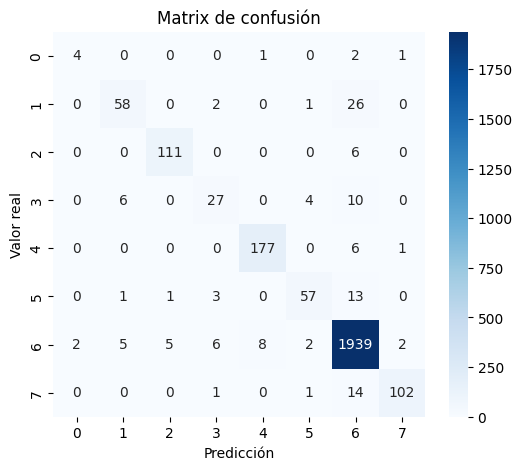

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión - XGBoost')
plt.show()


## Saving model

In [147]:
xgb.save_model("./models_saved/xgboost.json")

## Bayesian optimization

Function that will be used during the optimization

In [174]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),

        "random_state": seed,
        "n_jobs": -1
    }

    model = XGBRFClassifier(**params)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    return f1_score(y_test, y_pred, average = "weighted")

Optimization process

In [179]:
optimization = optuna.create_study(direction = "maximize")
optimization.optimize(objective, n_trials = 100)

[I 2025-04-15 10:10:56,543] A new study created in memory with name: no-name-a07fe98c-991d-430e-a7ab-7c5034187b22
[I 2025-04-15 10:10:57,419] Trial 0 finished with value: 0.9521005012965373 and parameters: {'n_estimators': 102, 'max_depth': 11, 'learning_rate': 0.07447065591352348, 'subsample': 0.9218166381970614}. Best is trial 0 with value: 0.9521005012965373.
[I 2025-04-15 10:10:58,396] Trial 1 finished with value: 0.8892941178946577 and parameters: {'n_estimators': 301, 'max_depth': 3, 'learning_rate': 0.2695003424292152, 'subsample': 0.596268208827258}. Best is trial 0 with value: 0.9521005012965373.
[I 2025-04-15 10:11:00,051] Trial 2 finished with value: 0.9503043196363441 and parameters: {'n_estimators': 233, 'max_depth': 12, 'learning_rate': 0.080826680710653, 'subsample': 0.5609408953634701}. Best is trial 0 with value: 0.9521005012965373.
[I 2025-04-15 10:11:02,059] Trial 3 finished with value: 0.9495457961467736 and parameters: {'n_estimators': 266, 'max_depth': 19, 'learni

In [184]:
print(f"Best parameters: {optimization.best_params}")

Best parameters: {'n_estimators': 496, 'max_depth': 17, 'learning_rate': 0.16460633107229694, 'subsample': 0.6993473658593062}


In [185]:
xgb = XGBRFClassifier(**optimization.best_params)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

In [186]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

Accuracy: 0.9543186180422265
F1 score: 0.9534079300378185


In [187]:
xgb.save_model("./models_saved/xgboost_opt.json")